In [ ]:
# Install the datasets library (Run once)
!pip install datasets

In [ ]:
# Import required libraries
from datasets import load_dataset
import pandas as pd


In [ ]:
# Load AG News dataset
dataset = load_dataset("wangrongsheng/ag_news")


README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
# Convert into DataFrame
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])


In [ ]:
# Display first few rows
print(train_df.head())

                                                text  label
0  Wall St. Bears Claw Back Into the Black (Reute...      2
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2
3  Iraq Halts Oil Exports from Main Southern Pipe...      2
4  Oil prices soar to all-time record, posing new...      2


In [ ]:
# Step 2: Clean and Normalize the Text
import re

# Function to clean text
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove numbers and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text


In [ ]:
# Apply cleaning
train_df["text"] = train_df["text"].apply(clean_text)
test_df["text"] = test_df["text"].apply(clean_text)

print(train_df["text"].head())

0    wall st bears claw back into the black reuters...
1    carlyle looks toward commercial aerospace reut...
2    oil and economy cloud stocks outlook reuters r...
3    iraq halts oil exports from main southern pipe...
4    oil prices soar to alltime record posing new m...
Name: text, dtype: object


In [ ]:
# Step 3: Convert Words into Numbers
from tensorflow.keras.preprocessing.text import Tokenizer

# Create tokenizer
tokenizer = Tokenizer(num_words=10000)

# Learn vocabulary
tokenizer.fit_on_texts(train_df["text"])

# Convert text into sequences
X_train = tokenizer.texts_to_sequences(train_df["text"])
X_test = tokenizer.texts_to_sequences(test_df["text"])

In [ ]:
# Step 4: Pad the Sequences
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Keep every sentence length equal
max_length = 50

X_train = pad_sequences(X_train,
                        maxlen=max_length,
                        padding="post",
                        truncating="post")

X_test = pad_sequences(X_test,
                       maxlen=max_length,
                       padding="post",
                       truncating="post")

print(X_train.shape)

(120000, 50)


In [ ]:
# Step 5: Convert Labels to One-Hot Encoding
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(train_df["label"])
y_test = to_categorical(test_df["label"])

print(y_train[0])

[0. 0. 1. 0.]


In [ ]:
# Step 6: Build the RNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Create model
model = Sequential()

# Word Embedding Layer
model.add(Embedding(input_dim=10000,
                    output_dim=64,
                    input_length=max_length))

# Simple RNN Layer
model.add(SimpleRNN(64))

# Output Layer
model.add(Dense(4, activation="softmax"))

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 7: Compile and Train the Model
# Compile the model
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - accuracy: 0.7431 - loss: 0.6762 - val_accuracy: 0.4332 - val_loss: 1.1402
Epoch 2/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 60s 20ms/step - accuracy: 0.3841 - loss: 1.2337 - val_accuracy: 0.3886 - val_loss: 1.2586
Epoch 3/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 58s 19ms/step - accuracy: 0.4102 - loss: 1.2439 - val_accuracy: 0.3915 - val_loss: 1.2605
Epoch 4/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 82s 19ms/step - accuracy: 0.4753 - loss: 1.1721 - val_accuracy: 0.3899 - val_loss: 1.2578
Epoch 5/5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 60s 20ms/step - accuracy: 0.4296 - loss: 1.2088 - val_accuracy: 0.6173 - val_loss: 1.0211


In [ ]:
# Step 8: Evaluate the Model
# Evaluate on test data
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6142 - loss: 1.0224
Test Loss : 1.0223987102508545
Test Accuracy : 0.6142105460166931


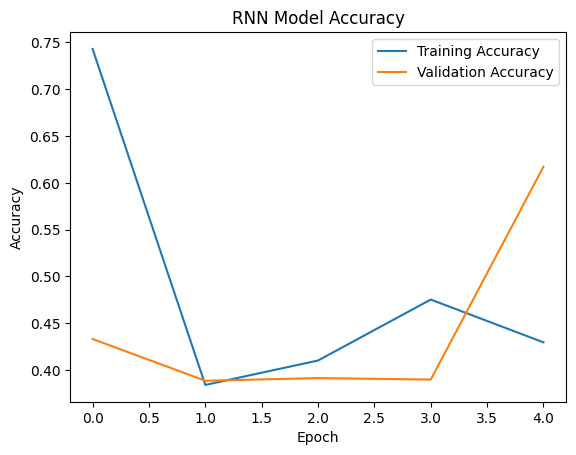

In [ ]:
import matplotlib.pyplot as plt

# Training Accuracy
plt.plot(history.history["accuracy"], label="Training Accuracy")

# Validation Accuracy
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Model Accuracy")

plt.legend()

plt.show()